In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

In [28]:
golden_mean = (np.sqrt(5) - 1) / 2  # Aesthetic ratio
# fig_width_pt = 246.0  # Columnwidth
fig_width_pt = 600.0  # Columnwidth
inches_per_pt = 1 / 72.27  # Convert pt to inches
fig_width = fig_width_pt * inches_per_pt
fig_height = fig_width * golden_mean  # height in inches
fig_size = [fig_width, fig_height]

params = {
    "backend": "ps",
    "axes.labelsize": 13,
    "font.size": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "text.usetex": True,
    "figure.figsize": fig_size,
    "font.family": "serif",
    "font.serif": "Computer Modern Roman",
    "legend.frameon": True,
    "savefig.dpi": 300,
}
plt.rcParams.update(params)
plt.rcParams.update({"text.usetex":True})

In [21]:
transistors = {500: (14.7, 0.5),
              350: (50, 2),
              240: (100, 14),
              144: (300, 10),
              40: (350, 0),
              67: (427, 0)}

In [22]:
channel_length = []
cutoff_list = []
maxfreq_list = []
for data in transistors.items():
    length, characteristic = data
    channel_length.append(length)
    cutoff, maxfreq = characteristic
    cutoff_list.append(cutoff)
    maxfreq_list.append(maxfreq) 

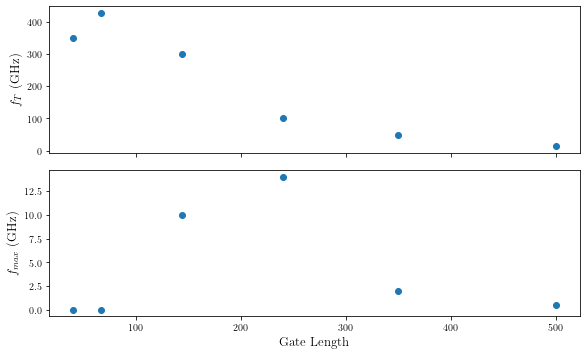

In [46]:
fig, axes = plt.subplots(2, sharex=True)
axes[0].scatter(np.array(channel_length), np.array(sorted(cutoff_list)))
axes[1].scatter(np.array(channel_length), np.array(maxfreq_list))
axes[1].set_xlabel('Gate Length')
axes[0].set_ylabel('$f_{T}$ (GHz)')
axes[1].set_ylabel('$f_{max}$ (GHz)')
fig.tight_layout()

In [2]:
# Transform atom-width in nm-width
#  conversion is worked out by considering 9-atom width for AGNR being large as well as 0.95 nm

atom_width = [6,7 ,7,9 ,12,13 ,15]
nm_width = [round(i*0.95/9, 2) for i in atom_width]
nm_width

[0.63, 0.74, 0.74, 0.95, 1.27, 1.37, 1.58]

In [14]:


eg = [1880,3100 ,1690 ,2370 ,2500 ,1690 ,1130 ,1600 ,1030 ,1400]


[7668331773067780.0, 1.5590421540150967e+26, 190253295013234.84, 1.0589179199239814e+20, 1.3282274949814354e+21, 190253295013234.84, 3529548505.78, 33028920396733.94, 504415305.64, 674578633077.65]


In [26]:
import math

def bandgap(ion_ioff_ratio):
    return round(math.log(ion_ioff_ratio)*2*(25.7),2)

def ion_ioff(bandgap):
    return round(math.exp(bandgap/(2*25.7)),2) 

bandgap_list = [1880,3100 ,1690 ,2370 ,2500 ,1690 ,1130 ,1600 ,1030 ,1400]
ion_ioff_list = [ion_ioff(i) for i in bandgap_list]


SyntaxError: invalid syntax (Temp/ipykernel_5808/46583565.py, line 10)

In [27]:
for i in ion_ioff_list:
    print(f'{i:.2e}')


7.67e+15
1.56e+26
1.90e+14
1.06e+20
1.33e+21
1.90e+14
3.53e+09
3.30e+13
5.04e+08
6.75e+11


1880            7.67e+15
3100            1.56e+26
1690            1.90e+14
2370            1.06e+20
2500            1.33e+21
1690            1.90e+14
1130            3.53e+09
1600            3.30e+13
1030            5.04e+08
1400            6.75e+11

In [ ]:
I_\textrm{on}/I_\textrm{off}

In [31]:
import statistics
mobility = [2_443, 1_609, 3_776]
statistics.mean(mobility)

2609.3333333333335

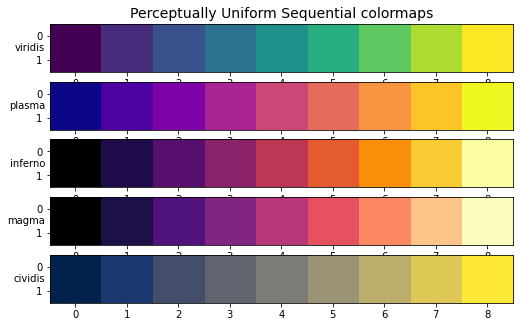

In [9]:
from collections import OrderedDict

cmaps = OrderedDict() # the advantage of having an orderd dict is that later in the for loop I don't have single element list thr and index
cmaps['Perceptually Uniform Sequential'] = ['viridis', 'plasma', 'inferno', 'magma', 'cividis']

def plot_save_gradients(cmap_category, cmap_list, number_points_colorscale:int =9):
    '''
    function adapted from the matplotlib website. Produces the colormap defined 
    '''
    
    gradient = np.linspace(0,1,number_points_colorscale)
    gradient = np.vstack((gradient, gradient))
    nrows = len(cmap_list)
    golden_mean = (np.sqrt(5) - 1) / 2  # Aesthetic ratio
    fig_width_pt = 600 # Columnwidth
    inches_per_pt = 1 / 72.27  # Convert pt to inches
    fig_width = fig_width_pt * inches_per_pt
    fig_height = fig_width * golden_mean  # height in inches
    fig_size = [fig_width, fig_height]
    fig, axs = plt.subplots(nrows=nrows, figsize=fig_size)
    axs[0].set_title(cmap_category + ' colormaps', fontsize=14)
    for ax, name in zip(axs, cmap_list):
        ax.imshow(gradient, aspect='auto', cmap=plt.get_cmap(name))
        ax.text(-.01, .5, name, va='center', ha='right', fontsize=10, transform=ax.transAxes)
    
for cmap_category, cmap_list in cmaps.items():
    plot_save_gradients(cmap_category, cmap_list)
plt.savefig('figures/uniform_sequential_colormap.png', dpi=300)
plt.savefig('figures/unform_sequential_colormap.pdf', dpi=300)

odict_keys(['Perceptually Uniform Sequential'])

In [11]:
def compute_image_size(width):
    """
    @parmas width: in pt
    """
    import numpy as np
    golden_mean = (np.sqrt(5) - 1) / 2  # Aesthetic ratio
    # fig_width_pt = 246.0  # Columnwidth
    fig_width_pt = width  # Columnwidth
    inches_per_pt = 1 / 72.27  # Convert pt to inches
    fig_width = fig_width_pt * inches_per_pt
    fig_height = fig_width * golden_mean  # height in inches
    return (fig_width, fig_height)

compute_image_size(1236)

(17.10253217102532, 10.569946175382178)

In [7]:
capacitance_gate_central_island = 1.602e-19/16e-3
E_c = 3e-3 # meV
total_capacitance = 1.602e-19 / E_c
total_capacitance

8.554680000000001e-17

In [10]:
import numpy as np
width_golden = lambda height: height / ((np.sqrt(5) - 1) / 2)
width_golden(15)

24.27050983124842

In [7]:
name = 'alessandro_lodi.dat_10_23.9840.png'
name_split = name.split('_')
name_split[-1].split('.')[0]

'23'